In [ ]:
#Supply Chain Demand Forecast & Inventory Optimization

In [1]:
# Import core libraries used in data analysis

import pandas as pd              # Used for handling datasets
import numpy as np               # Used for numerical calculations
import matplotlib.pyplot as plt  # Used for visualisation

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load the dataset

df = pd.read_csv("supply_chain_data.csv")

# View first 5 rows

df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [3]:
# Check dataset information

df.info()

# Summary statistics

df.describe()

# Check missing values

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    str    
 1   SKU                      100 non-null    str    
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    str    
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    str    
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    str    
 14  Location                 100 non-null 

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [4]:
# Extract demand data

demand = df[['SKU','Number of products sold']]

# View highest demand product

print(df.loc[df["Number of products sold"].idxmax()])

Product type                  skincare
SKU                              SKU10
Price                        15.707796
Availability                        11
Number of products sold            996
Revenue generated          2330.965802
Customer demographics       Non-binary
Stock levels                        51
Lead times                          13
Order quantities                    80
Shipping times                       2
Shipping carriers            Carrier C
Shipping costs                8.673211
Supplier name               Supplier 5
Location                       Kolkata
Lead time                           18
Production volumes                 830
Manufacturing lead time              5
Manufacturing costs          96.527353
Inspection results                Pass
Defect rates                  1.727314
Transportation modes              Road
Routes                         Route B
Costs                       806.103178
Name: 10, dtype: object


In [5]:
# Calculate moving average demand

window = 5  # last 5 observations

df['Demand Forecast'] = df['Number of products sold'].rolling(window).mean()

df[['SKU','Number of products sold','Demand Forecast']].head(10)

,SKU,Number of products sold,Demand Forecast
0,SKU0,802,NaN
1,SKU1,736,NaN
2,SKU2,8,NaN
3,SKU3,83,NaN
4,SKU4,871,500.0
5,SKU5,147,369.0
6,SKU6,65,234.8
7,SKU7,426,318.4
8,SKU8,150,331.8
9,SKU9,980,353.6


In [6]:
# Standard deviation of demand
demand_std = df['Number of products sold'].std()

# Average lead time
lead_time = df['Lead times'].mean()

# Service level factor (Z-score for 95% service level)
z = 1.65

# Safety stock formula
df['Safety Stock'] = z * demand_std * np.sqrt(lead_time)

df[['SKU','Safety Stock']].head()

,SKU,Safety Stock
0,SKU0,2002.440733
1,SKU1,2002.440733
2,SKU2,2002.440733
3,SKU3,2002.440733
4,SKU4,2002.440733


In [10]:
# Reorder Point tells us WHEN we should place a new order.

# Average demand
avg_demand = df['Number of products sold'].mean()

# Average lead time (time taken for supplier delivery)
lead_time = df['Lead times'].mean()

# Reorder Point Formula
# Reorder Point = (Average Demand × Lead Time) + Safety Stock

df['Reorder Point'] = (avg_demand * lead_time) + df['Safety Stock']

# View results
df[['SKU','Safety Stock','Reorder Point']].head()

,SKU,Safety Stock,Reorder Point
0,SKU0,2002.440733,9359.841133
1,SKU1,2002.440733,9359.841133
2,SKU2,2002.440733,9359.841133
3,SKU3,2002.440733,9359.841133
4,SKU4,2002.440733,9359.841133


In [11]:
# If current stock is less than or equal to reorder point → reorder

df['Reorder Decision'] = np.where(
    df['Stock levels'] <= df['Reorder Point'],
    "Reorder required",
    "Stock sufficient"
)

df[['SKU','Stock levels','Reorder Point','Reorder Decision']].head(15)

,SKU,Stock levels,Reorder Point,Reorder Decision
0,SKU0,58,9359.841133,Reorder required
1,SKU1,53,9359.841133,Reorder required
2,SKU2,1,9359.841133,Reorder required
3,SKU3,23,9359.841133,Reorder required
4,SKU4,5,9359.841133,Reorder required
5,SKU5,90,9359.841133,Reorder required
6,SKU6,11,9359.841133,Reorder required
7,SKU7,93,9359.841133,Reorder required
8,SKU8,5,9359.841133,Reorder required
9,SKU9,14,9359.841133,Reorder required


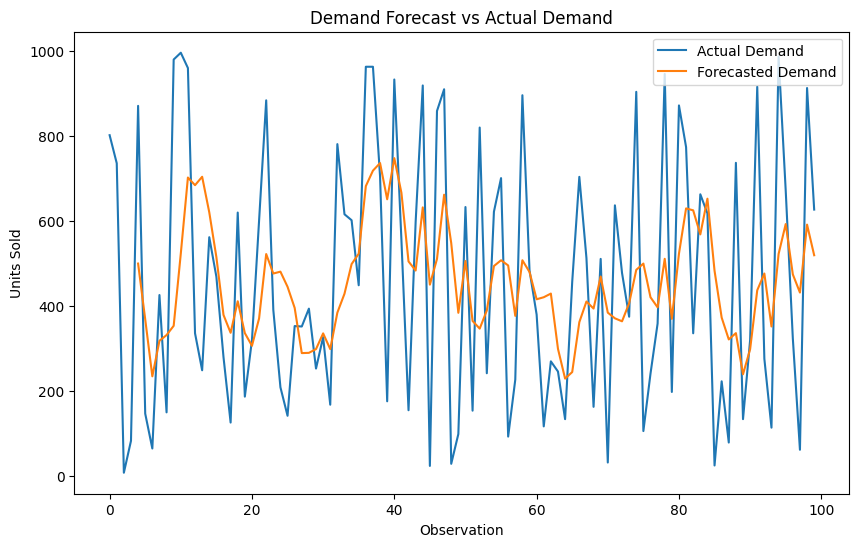

In [12]:
plt.figure(figsize=(10,6))

plt.plot(df['Number of products sold'], label='Actual Demand')
plt.plot(df['Demand Forecast'], label='Forecasted Demand')

plt.title("Demand Forecast vs Actual Demand")
plt.xlabel("Observation")
plt.ylabel("Units Sold")
plt.legend()

plt.show()

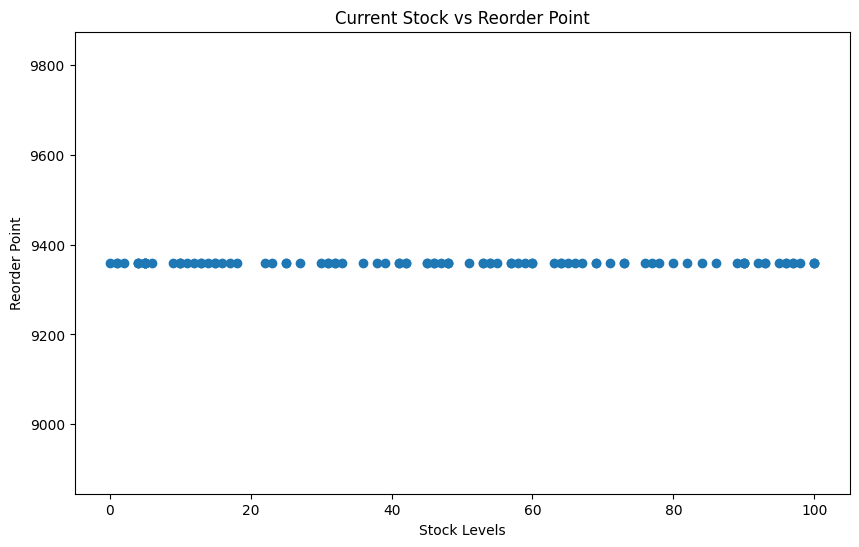

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(df['Stock levels'], df['Reorder Point'])

plt.title("Current Stock vs Reorder Point")
plt.xlabel("Stock Levels")
plt.ylabel("Reorder Point")

plt.show()

In [14]:
df[['SKU',
    'Number of products sold',
    'Demand Forecast',
    'Stock levels',
    'Safety Stock',
    'Reorder Point',
    'Reorder Decision']].head(20)

,SKU,Number of products sold,Demand Forecast,Stock levels,Safety Stock,Reorder Point,Reorder Decision
0,SKU0,802,NaN,58,2002.440733,9359.841133,Reorder required
1,SKU1,736,NaN,53,2002.440733,9359.841133,Reorder required
2,SKU2,8,NaN,1,2002.440733,9359.841133,Reorder required
3,SKU3,83,NaN,23,2002.440733,9359.841133,Reorder required
4,SKU4,871,500.0,5,2002.440733,9359.841133,Reorder required
5,SKU5,147,369.0,90,2002.440733,9359.841133,Reorder required
6,SKU6,65,234.8,11,2002.440733,9359.841133,Reorder required
7,SKU7,426,318.4,93,2002.440733,9359.841133,Reorder required
8,SKU8,150,331.8,5,2002.440733,9359.841133,Reorder required
9,SKU9,980,353.6,14,2002.440733,9359.841133,Reorder required


In [15]:
# Moving Average Forecast per SKU

window = 3  # last 3 observations

df['Demand Forecast'] = (
    df.groupby('SKU')['Number of products sold']
    .transform(lambda x: x.rolling(window, min_periods=1).mean())
)

df[['SKU','Number of products sold','Demand Forecast']].head(10)

,SKU,Number of products sold,Demand Forecast
0,SKU0,802,802.0
1,SKU1,736,736.0
2,SKU2,8,8.0
3,SKU3,83,83.0
4,SKU4,871,871.0
5,SKU5,147,147.0
6,SKU6,65,65.0
7,SKU7,426,426.0
8,SKU8,150,150.0
9,SKU9,980,980.0


In [16]:
# Standard deviation of demand per SKU
demand_std = df.groupby('SKU')['Number of products sold'].transform('std')

# Average lead time
lead_time = df['Lead times'].mean()

# Service level (95%)
z = 1.65

# Safety stock formula
df['Safety Stock'] = z * demand_std * np.sqrt(lead_time)

# Replace NaN values with 0
df['Safety Stock'] = df['Safety Stock'].fillna(0)

df[['SKU','Safety Stock']].head()

,SKU,Safety Stock
0,SKU0,0.0
1,SKU1,0.0
2,SKU2,0.0
3,SKU3,0.0
4,SKU4,0.0


In [17]:
# Average demand per SKU
avg_demand = df.groupby('SKU')['Number of products sold'].transform('mean')

# Reorder Point Formula
df['Reorder Point'] = (avg_demand * lead_time) + df['Safety Stock']

df[['SKU','Reorder Point']].head()

,SKU,Reorder Point
0,SKU0,12799.92
1,SKU1,11746.56
2,SKU2,127.68
3,SKU3,1324.68
4,SKU4,13901.16


In [18]:
# Decide if reorder is needed

df['Reorder Decision'] = np.where(
    df['Stock levels'] <= df['Reorder Point'],
    "Reorder required",
    "Stock sufficient"
)

df[['SKU','Stock levels','Reorder Point','Reorder Decision']].head(15)

,SKU,Stock levels,Reorder Point,Reorder Decision
0,SKU0,58,12799.92,Reorder required
1,SKU1,53,11746.56,Reorder required
2,SKU2,1,127.68,Reorder required
3,SKU3,23,1324.68,Reorder required
4,SKU4,5,13901.16,Reorder required
5,SKU5,90,2346.12,Reorder required
6,SKU6,11,1037.40,Reorder required
7,SKU7,93,6798.96,Reorder required
8,SKU8,5,2394.00,Reorder required
9,SKU9,14,15640.80,Reorder required


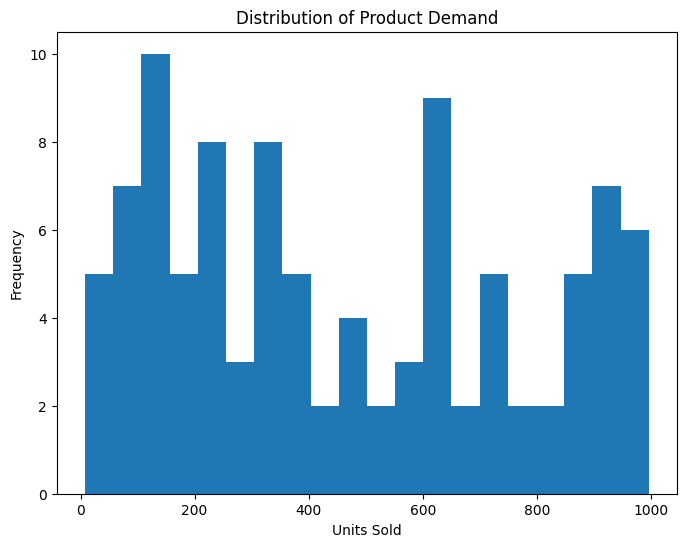

In [19]:
#Visualization — Demand Distribution

plt.figure(figsize=(8,6))

plt.hist(df['Number of products sold'], bins=20)

plt.title("Distribution of Product Demand")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

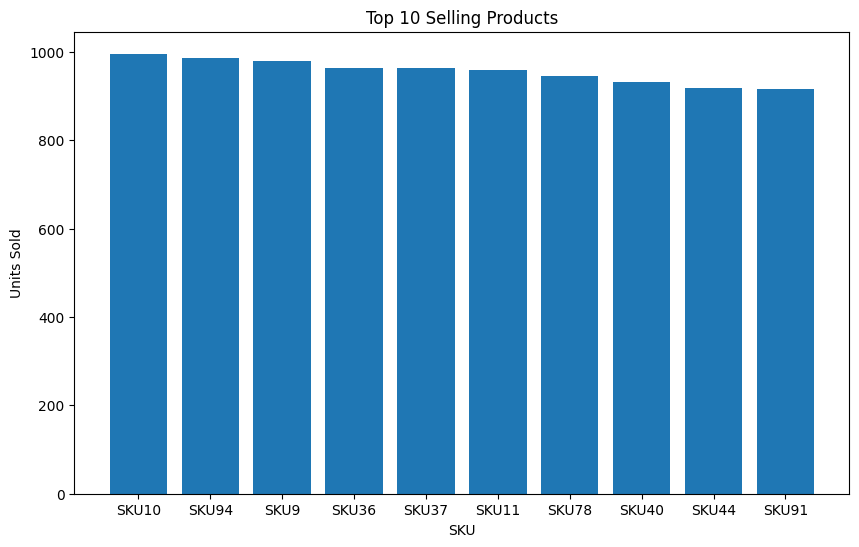

In [20]:
#Visualization -— Top Selling SKUs

top_products = df.sort_values(
    by='Number of products sold',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(top_products['SKU'], top_products['Number of products sold'])

plt.title("Top 10 Selling Products")
plt.xlabel("SKU")
plt.ylabel("Units Sold")

plt.show()

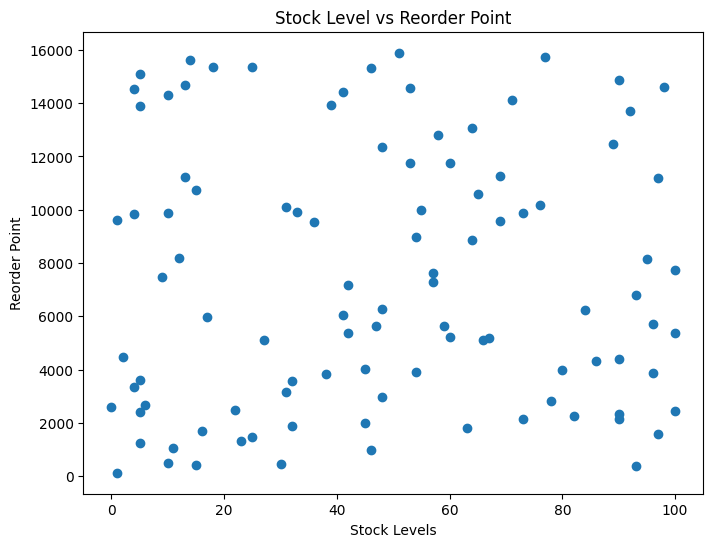

In [21]:
#Visualization -— Stock vs Reorder Point

plt.figure(figsize=(8,6))

plt.scatter(df['Stock levels'], df['Reorder Point'])

plt.title("Stock Level vs Reorder Point")
plt.xlabel("Stock Levels")
plt.ylabel("Reorder Point")

plt.show()

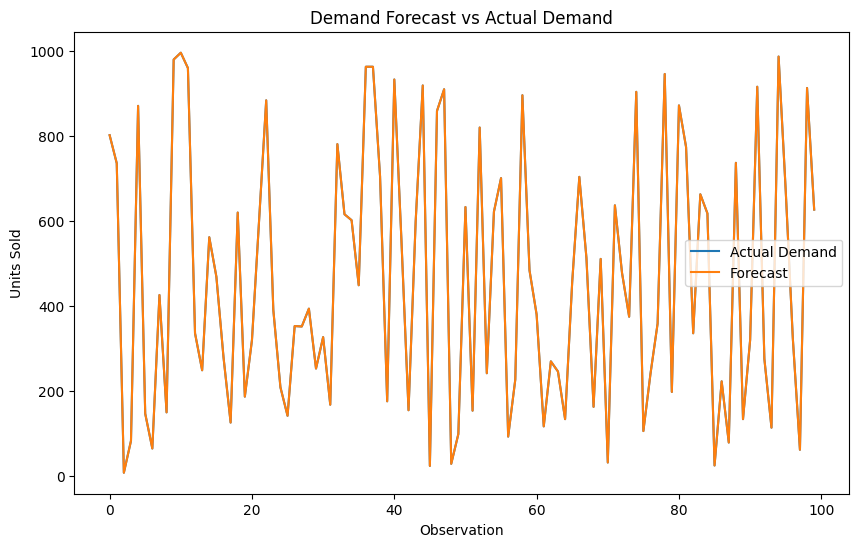

In [22]:
#Visualization -— Forecast vs Actual Demand

plt.figure(figsize=(10,6))

plt.plot(df['Number of products sold'], label="Actual Demand")
plt.plot(df['Demand Forecast'], label="Forecast")

plt.title("Demand Forecast vs Actual Demand")
plt.xlabel("Observation")
plt.ylabel("Units Sold")
plt.legend()

plt.show()

In [23]:
###Final Project Output###

df[['SKU',
    'Number of products sold',
    'Demand Forecast',
    'Stock levels',
    'Safety Stock',
    'Reorder Point',
    'Reorder Decision']].head(20)

,SKU,Number of products sold,Demand Forecast,Stock levels,Safety Stock,Reorder Point,Reorder Decision
0,SKU0,802,802.0,58,0.0,12799.92,Reorder required
1,SKU1,736,736.0,53,0.0,11746.56,Reorder required
2,SKU2,8,8.0,1,0.0,127.68,Reorder required
3,SKU3,83,83.0,23,0.0,1324.68,Reorder required
4,SKU4,871,871.0,5,0.0,13901.16,Reorder required
5,SKU5,147,147.0,90,0.0,2346.12,Reorder required
6,SKU6,65,65.0,11,0.0,1037.40,Reorder required
7,SKU7,426,426.0,93,0.0,6798.96,Reorder required
8,SKU8,150,150.0,5,0.0,2394.00,Reorder required
9,SKU9,980,980.0,14,0.0,15640.80,Reorder required
